# Домашнее задание "Продвинутая линейная алгебра".

## Уровень 0:


### Задание 1

Дан объект в $2D$ пространстве

(-200.0, 200.0)

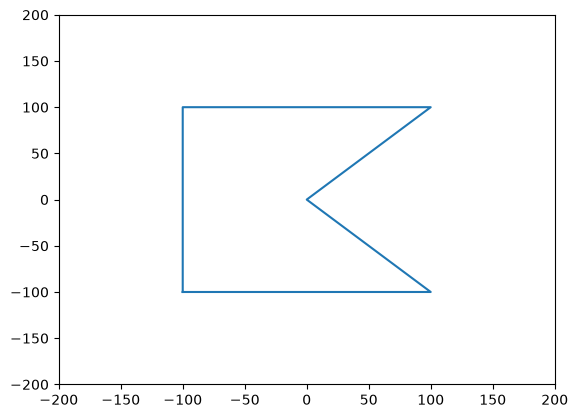

In [1]:
import numpy as np
import matplotlib.pyplot as plt

A = [
[-100, -100, 1],
[-100, 100, 1],
[100, 100, 1],
[0, 0, 1],
[100, -100, 1],
[-100, -100, 1]
]

A = np.array(A)

x = A[:,0]
y = A[:,1]
plt.plot(x, y)
plt.ylim([-200, 200])
plt.xlim([-200, 200]) 

При помощи линейных отображений:
- Уменьшить объект в два раза
- Повернуть на 130 градусов
- Отразить объект относительно прямой y=x (поможет матрица `[[0, 1, 0], [1, 0, 0], [0, 0, 1]]`)


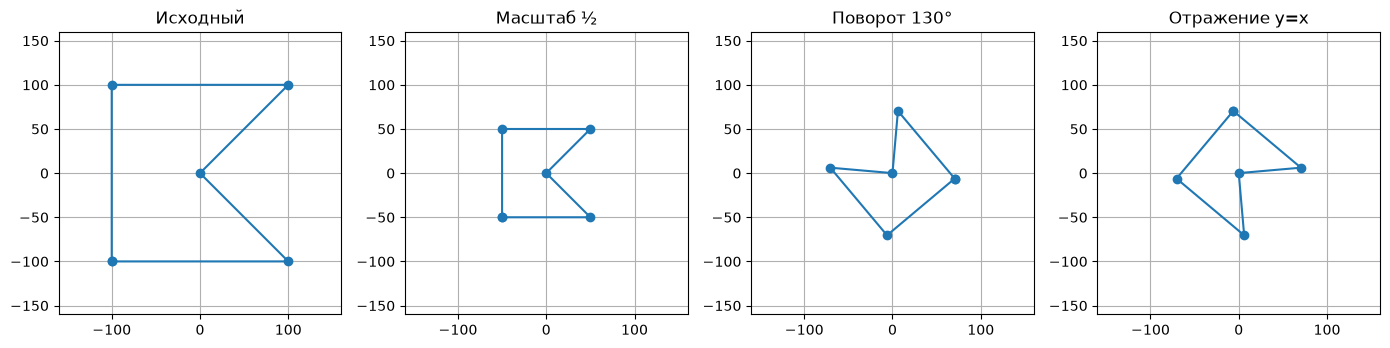

In [2]:
theta = np.deg2rad(130)
S = np.diag([0.5,0.5,1])
R = np.array([[np.cos(theta),-np.sin(theta),0], [np.sin(theta),np.cos(theta),0], [0,0,1]])
F = np.array([[0,1,0],[1,0,0],[0,0,1]])
# Точки записаны строками: умножаем на транспонированную матрицу.
scaled = A @ S.T
rotated = scaled @ R.T
reflected = rotated @ F.T
assert np.allclose(np.linalg.norm(scaled[:,:2],axis=1), np.linalg.norm(A[:,:2],axis=1)/2)
assert np.allclose(reflected[:,:2], rotated[:,[1,0]])
fig, axes = plt.subplots(1,4,figsize=(14,4))
for ax, points, title in zip(axes, [A,scaled,rotated,reflected], ['Исходный','Масштаб ½','Поворот 130°','Отражение y=x']):
    ax.plot(points[:,0],points[:,1], marker='o')
    ax.set(xlim=(-160,160), ylim=(-160,160), title=title)
    ax.set_aspect('equal'); ax.grid()
plt.tight_layout(); plt.show()

## Уровень 1:

### Задание 2

Найдите спектральное разложение матрицы:
```
m = np.array([[1, 2],
              [2, 3]])
print(m)
```



In [3]:
m = np.array([[1,2],[2,3]])
values, Q = np.linalg.eigh(m)
Lambda = np.diag(values)
assert np.allclose(Q.T @ Q, np.eye(2))
assert np.allclose(Q @ Lambda @ Q.T, m)
print('Собственные значения:',values)
print('Q:',Q, '\nΛ:',Lambda, '\nQΛQᵀ:', Q @ Lambda @ Q.T)

Собственные значения: [-0.23606798  4.23606798]
Q: [[-0.85065081  0.52573111]
 [ 0.52573111  0.85065081]] 
Λ: [[-0.23606798  0.        ]
 [ 0.          4.23606798]] 
QΛQᵀ: [[1. 2.]
 [2. 3.]]


## Решение и проверка

Решение подготовлено AI по запросу владельца репозитория. Выполнение подтверждает работоспособность кода; самостоятельное владение материалом не оценивалось.

Преобразования применены последовательно: масштабирование → поворот против часовой стрелки → отражение. Спектральное разложение: M = QΛQᵀ, λ = 2 ± √5.